In [36]:
import matplotlib.pyplot as plt
plt.rcParams["figure.dpi"] = 300
plt.rcParams['hatch.linewidth'] = 0.3
import pandas as pd
import stylia
stylia.set_style("ersilia")
nc = stylia.NamedColors() 
import json
import os

In [39]:
datasets = [["chembl", "chembl4649948"], 
            ["chembl", "chembl4659961"], 
            ["tdc", "ames"], 
            ["tdc", "bbb_martins"], 
            ["tdc", "bioavailability_ma"], 
            ["tdc", "carcinogens_lagunin"], 
            ["tdc", "clintox"], ["tdc", "cyp1a2_veith"], 
            ["tdc", "cyp2c19_veith"], 
            ["tdc", "cyp2c9_substrate_carbonmangels"], 
            ["tdc", "cyp2c9_veith"], 
            ["tdc", "cyp2d6_substrate_carbonmangels"], 
            ["tdc", "cyp2d6_veith"], 
            ["tdc", "cyp3a4_substrate_carbonmangels"], 
            ["tdc", "cyp3a4_veith"], 
            ["tdc", "dili"], ["tdc", "herg"], 
            ["tdc", "hia_hou"], 
            ["tdc", "pgp_broccatelli"], 
            ["tdc", "skin_reaction"],
            ["gardp", "abaumannii_inh_avg_bin"],
            ["gardp", "kpneumoniae_atcc_43816_inh_avg_bin"],
            ["gardp", "kpneumoniae_ecl8_inh_avg_bin"],
            ["gardp", "kpneumoniae_nctc_13438_inh_avg_bin"]]

PATH_TO_EOSBENCH_DATA = os.path.join("/home/acomajuncosa/github/eosbench/src/eosbench/_data")
PATH_TO_EOSBENCH_RESULTS = os.path.join("/home/acomajuncosa/github/chembl-antimicrobial-models/output/results/03_eosbench")

In [38]:
# Create results df
files = sorted(os.listdir(PATH_TO_EOSBENCH_RESULTS))
df = pd.concat([pd.read_csv(os.path.join(PATH_TO_EOSBENCH_RESULTS, f)) for f in files], ignore_index=True)

# Read metadata
metadata = {}
for dataset in datasets:
    source, dataset = dataset
    with open(os.path.join(PATH_TO_EOSBENCH_DATA, source, "classification", dataset, "metadata.json")) as f:
        metadata[dataset] = json.load(f)

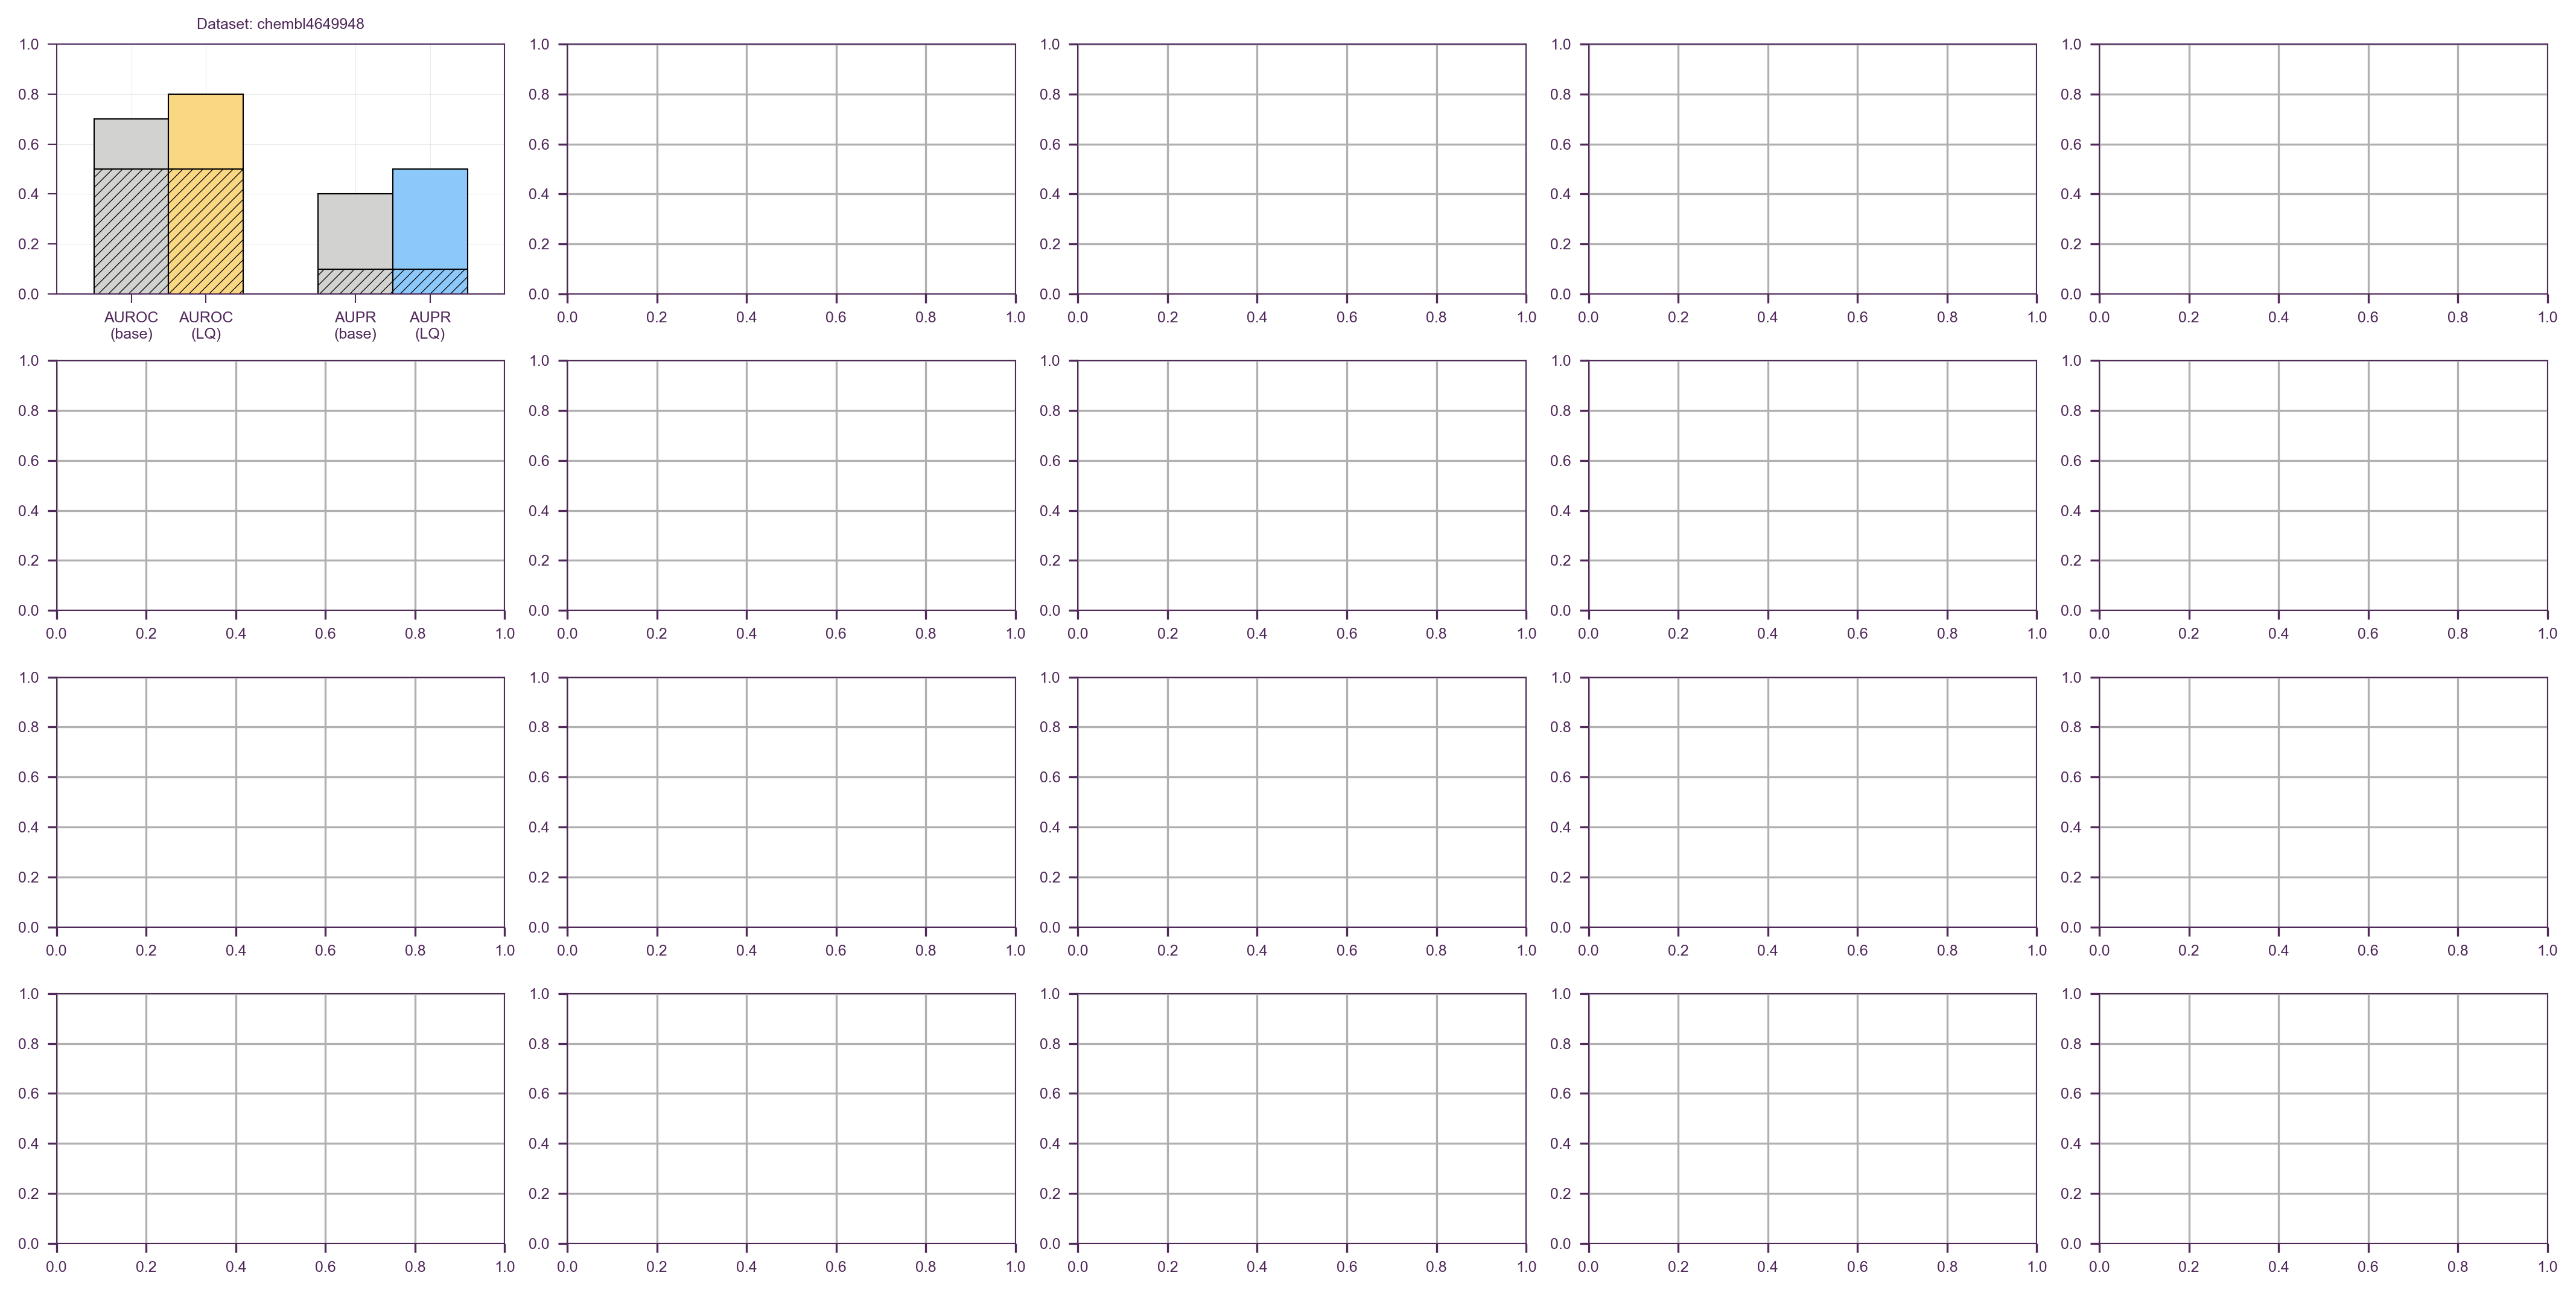

In [35]:
stylia.set_format("print")

fig, axs = stylia.create_figure(4, 5, width=2, height=1)

for source, dataset in datasets:

    ax = axs.next()
    ax.set_title(f"Dataset: {dataset}")
    ax.set_ylim([0, 1])
    ax.set_ylabel("")
    ax.set_xlabel("")
    ax.set_xlim([0, 6])
    x = [1, 2, 4, 5]
    ax.set_xticks(x)
    ax.set_xticklabels(['AUROC\n(base)', 'AUROC\n(LQ)', 'AUPR\n(base)', 'AUPR\n(LQ)'])
    

    w = 1
    y1 = [0.7, 0.8, 0.4, 0.5]
    y2 = [0.1, 0.1, 0.1, 0.1]
    y_baseline = [0.5, 0.5, 0.1, 0.1]
    colors = [nc.gray, nc.yellow, nc.gray, nc.blue]

    for i in range(len(x)):
    
        ax.bar(x[i], y1[i], color=colors[i], width=w, ec='k', lw=0.5)
        ax.bar(x[i], y_baseline[i], color=colors[i], width=w, ec='k', lw=0.5, hatch='/'*6)


    break

plt.tight_layout()
plt.show()